In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Ready!")

Ready!


In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# load etsy data which has sales and rating
df_e = pd.read_csv('data/etsy_clean.csv')
df_e = df_e.dropna(subset=['sale_price', 'rating', 'sales'])

print(f"Rows with complete data: {len(df_e)}")
print(df_e[['title', 'sale_price', 'rating', 'sales']].head())

Rows with complete data: 0
Empty DataFrame
Columns: [title, sale_price, rating, sales]
Index: []


In [3]:
print(df_e['sales'].value_counts())
print(df_e['sales'].isnull().sum())


Series([], Name: count, dtype: int64)
0


In [4]:
df_e = pd.read_csv('data/etsy_clean.csv')
df_e = df_e.dropna(subset=['sale_price', 'rating'])

# create success label
df_e['success'] = (df_e['rating'] >= 4.7).astype(int)

print(f"Total rows: {len(df_e)}")
print(f"\nSuccess distribution:")
print(df_e['success'].value_counts())
print(f"\nHigh performers: {df_e['success'].sum()}")
print(f"Low performers: {len(df_e) - df_e['success'].sum()}")


Total rows: 120

Success distribution:
success
1    83
0    37
Name: count, dtype: int64

High performers: 83
Low performers: 37


In [5]:
# add features
df_e['title_length'] = df_e['title'].str.len()
df_e['has_embroidered'] = df_e['title'].str.lower().str.contains('embroidered').astype(int)
df_e['has_kani'] = df_e['title'].str.lower().str.contains('kani').astype(int)
df_e['has_luxury'] = df_e['title'].str.lower().str.contains('luxury').astype(int)
df_e['has_handmade'] = df_e['title'].str.lower().str.contains('handmade').astype(int)
df_e['has_authentic'] = df_e['title'].str.lower().str.contains('authentic').astype(int)
df_e['discount_pct'] = df_e['discount'].str.replace('(','').str.replace('% off)','').str.strip()
df_e['discount_pct'] = pd.to_numeric(df_e['discount_pct'], errors='coerce').fillna(0)

features = ['sale_price', 'title_length', 'has_embroidered', 'has_kani',
            'has_luxury', 'has_handmade', 'has_authentic', 'discount_pct']

X = df_e[features]
y = df_e['success']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.93      0.93      0.93        14

    accuracy                           0.92        24
   macro avg       0.91      0.91      0.91        24
weighted avg       0.92      0.92      0.92        24



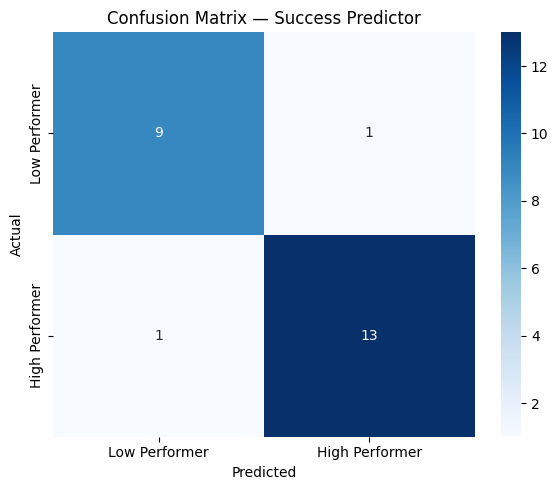

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Performer', 'High Performer'],
            yticklabels=['Low Performer', 'High Performer'])
plt.title('Confusion Matrix — Success Predictor')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [7]:
def predict_success(title, sale_price, discount_pct):
    features_input = pd.DataFrame([[
        sale_price,
        len(title),
        1 if 'embroidered' in title.lower() else 0,
        1 if 'kani' in title.lower() else 0,
        1 if 'luxury' in title.lower() else 0,
        1 if 'handmade' in title.lower() else 0,
        1 if 'authentic' in title.lower() else 0,
        discount_pct
    ]], columns=features)

    prediction = model.predict(features_input)[0]
    probability = model.predict_proba(features_input)[0][1]

    result = "HIGH PERFORMER ✅" if prediction == 1 else "LOW PERFORMER ❌"
    print(f"Title: {title}")
    print(f"Prediction: {result}")
    print(f"Success Probability: {probability*100:.1f}%")
    print()

# test with two listings
predict_success(
    title="Authentic Hand Embroidered Kani Pashmina Shawl Luxury Kashmiri Wrap",
    sale_price=25000,
    discount_pct=20
)

predict_success(
    title="Soft Pashmina Wrap",
    sale_price=5000,
    discount_pct=50
)

Title: Authentic Hand Embroidered Kani Pashmina Shawl Luxury Kashmiri Wrap
Prediction: HIGH PERFORMER ✅
Success Probability: 73.0%

Title: Soft Pashmina Wrap
Prediction: LOW PERFORMER ❌
Success Probability: 47.0%



In [13]:
import pickle

with open('models/success_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('models/success_features.pkl', 'wb') as f:
    pickle.dump(features, f)

print("Success model saved!")

Success model saved!
